# Chapter 12 Lab — fMRI Basics and Terminology (Python)

In this lab you will build a small 4-D fMRI dataset from scratch and connect the chapter's vocabulary — voxels, slices, volumes, TR, voxel space, world space, and image orientation — to the actual data structures used in analysis. We follow a five-step arc:

1. **Simulate a 4-D dataset**: a "brain" of voxels sampled once per TR, with one active region
2. **Wrap it in a NIfTI image** with nibabel, setting the affine matrix and header, and save/reload it
3. **Convert between voxel (matrix) space and world (mm) space** using the affine
4. **Extract and plot one voxel's time series** — the fundamental object of fMRI analysis
5. **Display slice montages**, and see the difference between radiological and neurological orientation

Because we build the dataset ourselves, every piece of terminology maps onto a line of code you wrote.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter environment with `numpy`, `matplotlib`, and `nibabel` installed. Each cell takes at most a few seconds. See the [chapter page](../ch12-fmri-basics-and-terminology.md) for the concepts behind the code.

In [ ]:
# Setup — needed when running in your browser or on Colab (safe to re-run anywhere)
%pip install -q nilearn


In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nibabel.affines import apply_affine

np.set_printoptions(precision=2, suppress=True)
print("numpy", np.__version__, "| nibabel", nib.__version__)

numpy 2.4.6 | nibabel 5.4.2


## Step 1 — Simulate a 4-D dataset

An fMRI **run** is a time series of 3-D **volumes**, one acquired every **TR**. We simulate a tiny run:

- volume dimensions **20 × 24 × 12 voxels** (x, y, z) — a "matrix size" of 20 × 24 with 12 slices
- **3 mm isotropic voxels**, so the field of view is 60 × 72 × 36 mm
- **60 volumes** at **TR = 2 s** — a 2-minute run

The "brain" is an ellipsoid with baseline intensity 400 (arbitrary units — remember, absolute fMRI values carry no meaning). One small region is "active": its signal increases by 2% during 20-second task blocks that alternate with 20 seconds of rest — a block ("boxcar") design. Real BOLD responses are also blurred and delayed by the hemodynamic response function; we keep the simulation simple here and take up the HRF in Chapter 18.

In [2]:
rng = np.random.default_rng(12)

nx, ny, nz, nt = 20, 24, 12, 60          # x, y, z, time
voxel_size, tr = 3.0, 2.0                # mm, seconds

# --- A "brain": an ellipsoid mask centered in the volume -------------------
i, j, k = np.meshgrid(np.arange(nx), np.arange(ny), np.arange(nz), indexing="ij")
center = np.array([(nx - 1) / 2, (ny - 1) / 2, (nz - 1) / 2])
brain_mask = ((i - center[0]) / 8) ** 2 + ((j - center[1]) / 10) ** 2 \
           + ((k - center[2]) / 5) ** 2 <= 1.0

# --- Baseline 400 inside the brain, plus scanner noise ---------------------
data = np.zeros((nx, ny, nz, nt), dtype=np.float32)
data[brain_mask, :] = 400.0
data += rng.normal(0, 5, size=data.shape).astype(np.float32) * brain_mask[..., None]

# --- An "active" region: a small sphere with a 2% boxcar task signal -------
active_center = np.array([14, 12, 6])    # voxel coordinates [i, j, k]
active_mask = np.sum((np.stack([i, j, k], -1) - active_center) ** 2, axis=-1) <= 4
active_mask &= brain_mask

block_len = int(20 / tr)                 # 20-s blocks = 10 TRs
task = (np.arange(nt) // block_len) % 2  # 0 = rest, 1 = task
data[active_mask, :] += 400.0 * 0.02 * task    # +2% signal during task

print(f"data shape (x, y, z, t): {data.shape}")
print(f"{brain_mask.sum()} brain voxels of {brain_mask.size} in the volume "
      f"({active_mask.sum()} active)")
print(f"run length: {nt} volumes x TR {tr} s = {nt * tr:.0f} s")

data shape (x, y, z, t): (20, 24, 12, 60)
1680 brain voxels of 5760 in the volume (33 active)
run length: 60 volumes x TR 2.0 s = 120 s


## Step 2 — Wrap the array in a NIfTI image

Scanners export DICOM files (one slice per time point per file — millions of files per study); analysis begins by converting to **NIfTI**, which stores an entire 4-D run in one file. A NIfTI image is essentially three things:

1. the **data array** (here 4-D: x, y, z, time)
2. the **affine matrix**: a 4 × 4 matrix mapping voxel indices to world (mm) coordinates
3. the **header**: meta-data including the "zooms" — voxel sizes in mm, and the TR as the 4th zoom

We build the affine for 3 mm isotropic voxels in the **LPI convention** (x: left → right, y: posterior → anterior, z: inferior → superior), with the world origin at the center of the volume — in real data, the origin sits at the anterior commissure.

In [3]:
affine = np.diag([voxel_size, voxel_size, voxel_size, 1.0])
affine[:3, 3] = -center * voxel_size     # world (0, 0, 0) at the volume center

img = nib.Nifti1Image(data, affine)
img.header.set_zooms((voxel_size,) * 3 + (tr,))   # 4th zoom = TR in seconds

print("shape:", img.shape)
print("zooms (mm, mm, mm, s):", img.header.get_zooms())
print("affine:\n", img.affine)

shape: (20, 24, 12, 60)
zooms (mm, mm, mm, s): (np.float32(3.0), np.float32(3.0), np.float32(3.0), np.float32(2.0))
affine:
 [[  3.    0.    0.  -28.5]
 [  0.    3.    0.  -34.5]
 [  0.    0.    3.  -16.5]
 [  0.    0.    0.    1. ]]


In [4]:
# NIfTI round trip: save to disk (.nii.gz) and reload
tmpdir = tempfile.mkdtemp()
fname = os.path.join(tmpdir, "sim_bold.nii.gz")
nib.save(img, fname)

img2 = nib.load(fname)
print(f"reloaded {os.path.basename(fname)}: shape {img2.shape}, "
      f"TR = {img2.header.get_zooms()[3]} s")
print("data identical:", np.allclose(img2.get_fdata(dtype=np.float32), data))

reloaded sim_bold.nii.gz: shape (20, 24, 12, 60), TR = 2.0 s
data identical: True


## Step 3 — Voxel space vs. world space

The data array is indexed by **voxel coordinates** `[i, j, k]` — plain matrix indices with no physical meaning. **World coordinates** `[x, y, z]` are in millimeters relative to the origin. The affine converts voxel → world; its inverse converts world → voxel:

$$\begin{bmatrix} x \\ y \\ z \\ 1 \end{bmatrix} = \mathbf{A} \begin{bmatrix} i \\ j \\ k \\ 1 \end{bmatrix}$$

Reading an affine at a glance:

- the (absolute) diagonal values are the **voxel sizes** in mm
- the last column encodes the **origin** (where voxel [0, 0, 0] sits in mm)
- a **negative first diagonal element** means the stored x-axis runs right-to-left — the image is stored "radiologically" and software must flip it for neurological display
- off-diagonal values encode rotations (e.g., oblique acquisitions)

In [5]:
# Voxel -> world: where is the active region's center in mm?
mm = apply_affine(affine, active_center)
print(f"active-region center: voxel {active_center} -> {mm} mm")

# World -> voxel: invert the affine
inv = np.linalg.inv(affine)
vox = apply_affine(inv, [0.0, 0.0, 0.0])
print(f"world origin [0, 0, 0] mm -> voxel {vox}  (the volume center)")

# The center voxel of the volume maps back to ~[0, 0, 0] mm:
print(f"voxel {center} -> {apply_affine(affine, center)} mm")

# A radiologically-stored image would have a NEGATIVE x scaling instead:
affine_radiological = affine.copy()
affine_radiological[0, 0] *= -1
affine_radiological[0, 3] *= -1
print("\nradiological-storage affine (note the -3 in the x position):")
print(affine_radiological)

active-region center: voxel [14 12  6] -> [13.5  1.5  1.5] mm
world origin [0, 0, 0] mm -> voxel [ 9.5 11.5  5.5]  (the volume center)
voxel [ 9.5 11.5  5.5] -> [0. 0. 0.] mm

radiological-storage affine (note the -3 in the x position):
[[ -3.    0.    0.   28.5]
 [  0.    3.    0.  -34.5]
 [  0.    0.    3.  -16.5]
 [  0.    0.    0.    1. ]]


## Step 4 — One voxel's time series

Fix a voxel's position and extract its intensity at every TR: that is a **time series**, the raw material of all fMRI analysis. We plot the active voxel against a "quiet" voxel elsewhere in the brain, shading the task blocks. The task effect is small relative to the baseline — which is why we quantify **percentage signal change** rather than raw units, and why statistical analysis is needed to separate signal from noise.

active voxel percent signal change: 2.20%  (true value: 2%)


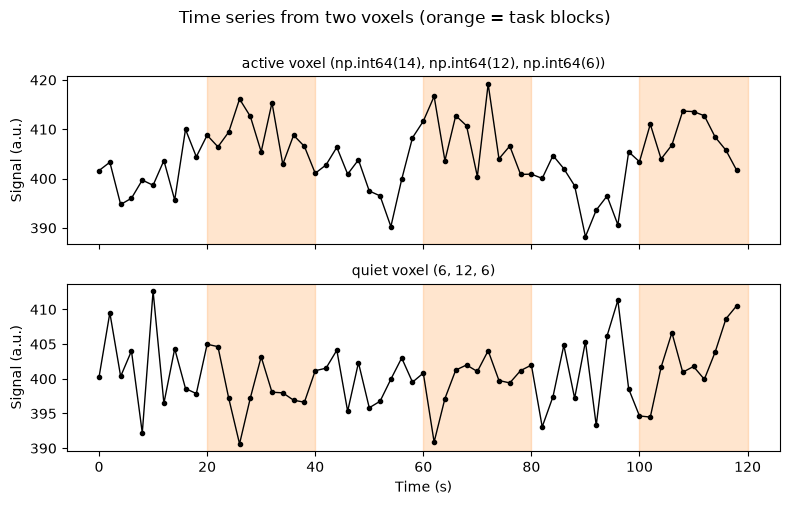

In [6]:
ts_active = data[tuple(active_center)].copy()            # active voxel
quiet_voxel = (6, 12, 6)
ts_quiet = data[quiet_voxel].copy()                       # quiet voxel

t = np.arange(nt) * tr

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for ax, ts, name in [(axes[0], ts_active, f"active voxel {tuple(active_center)}"),
                     (axes[1], ts_quiet, f"quiet voxel {quiet_voxel}")]:
    for b in range(0, nt, 2 * block_len):                 # shade task blocks
        ax.axvspan((b + block_len) * tr, (b + 2 * block_len) * tr,
                   color="tab:orange", alpha=0.2)
    ax.plot(t, ts, "k.-", lw=1)
    ax.set_ylabel("Signal (a.u.)")
    ax.set_title(name, fontsize=10)
axes[1].set_xlabel("Time (s)")
fig.suptitle("Time series from two voxels (orange = task blocks)", y=1.0)
fig.tight_layout()

# Percent signal change in the active voxel: (task - rest) / rest * 100
pct = 100 * (ts_active[task == 1].mean() - ts_active[task == 0].mean()) \
          / ts_active[task == 0].mean()
print(f"active voxel percent signal change: {pct:.2f}%  (true value: 2%)")

## Step 5 — Slice montages

A **montage** displays a volume as a grid of 2-D slices — the standard way to view a whole brain at once. Here we show every axial slice of the mean volume (averaged over time), labeled with its z position in mm computed from the affine. Note the terminology at work: 12 **slices**, each a 20 × 24 **matrix** of voxels.

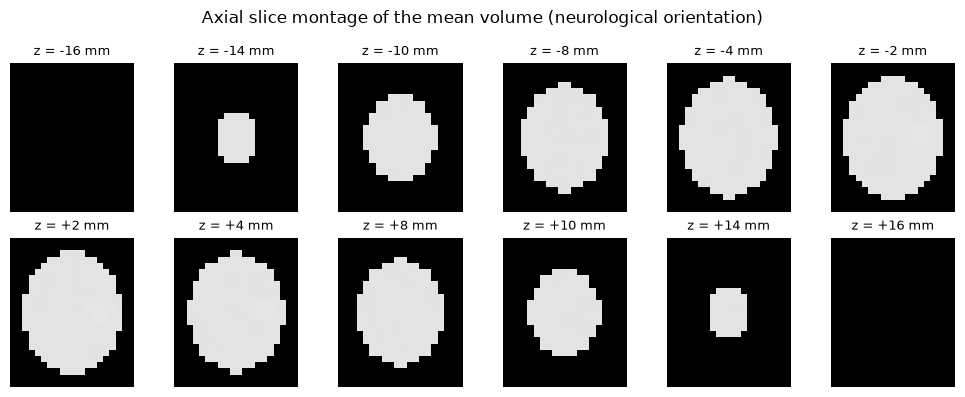

In [7]:
mean_vol = data.mean(axis=3)

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for kk, ax in enumerate(axes.ravel()):
    # .T puts x horizontal; origin="lower" puts +y (anterior) at the top
    ax.imshow(mean_vol[:, :, kk].T, cmap="gray", origin="lower",
              vmin=0, vmax=450)
    z_mm = apply_affine(affine, [0, 0, kk])[2]
    ax.set_title(f"z = {z_mm:+.0f} mm", fontsize=9)
    ax.axis("off")
fig.suptitle("Axial slice montage of the mean volume (neurological orientation)")
fig.tight_layout()

## Step 6 — Radiological vs. neurological orientation

The brain is nearly left–right symmetric, so it is dangerously easy to display an image flipped without noticing. Two conventions coexist:

- **Radiological** format: the brain's **left** is on the **right** of the image (viewing the patient from the feet)
- **Neurological** format: the brain's **right** is on the **right** of the image (standard in cognitive neuroscience)

Below, the same axial slice is shown both ways. The active region — which we placed at **positive x, i.e. the right hemisphere** — switches sides of the *display* while remaining in the same hemisphere of the *brain*. In real data, "flipping errors" arise when header conventions are mishandled; safeguards include consistent software use, fiducial markers, and anatomical asymmetries ("left looms larger" — the calcarine fissure deviates rightward).

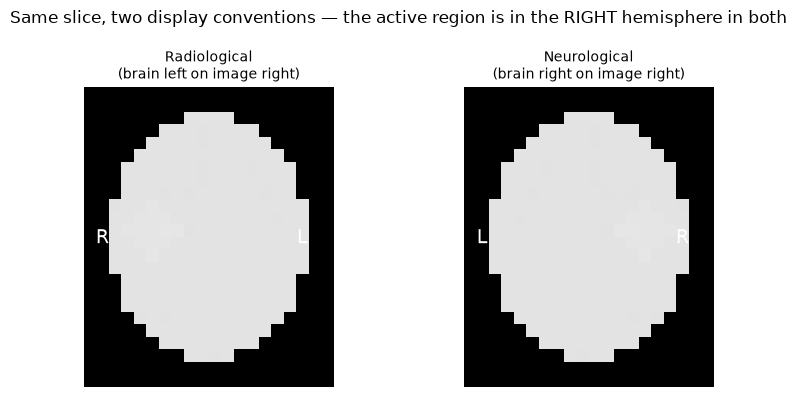

In [8]:
z = active_center[2]
sl = data[:, :, z, :].mean(axis=-1)      # mean over time, slice through active region

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, flip, name in [(axes[0], True, "Radiological\n(brain left on image right)"),
                       (axes[1], False, "Neurological\n(brain right on image right)")]:
    im = sl[::-1, :] if flip else sl     # flip the x (left-right) axis
    ax.imshow(im.T, cmap="gray", origin="lower", vmin=0, vmax=450)
    left_x, right_x = (17, 1) if flip else (1, 17)
    ax.text(left_x, 11, "L", color="w", fontsize=14, ha="center")
    ax.text(right_x, 11, "R", color="w", fontsize=14, ha="center")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
fig.suptitle("Same slice, two display conventions — the active region is in the "
             "RIGHT hemisphere in both")
fig.tight_layout()

## Explore on your own

1. **Change the geometry.** Rebuild the affine for anisotropic 3 × 3 × 5 mm voxels (a classic acquisition). What changes in the header zooms, the affine, and the z labels of your montage?
2. **Break the origin.** Shift the affine's translation so the origin is no longer at the volume center, and re-run the voxel ↔ world conversions. Where does world [0, 0, 0] land now? This is exactly what "setting the origin at the anterior commissure" does in real data.
3. **Make a flipping error on purpose.** Negate the affine's x scaling (and adjust its x translation) without flipping the data array, save, and reload with nibabel. Use `nib.aff2axcodes(img.affine)` to see how the orientation codes change — this is how software knows (or fails to know) which side is left.
4. **Hierarchy.** Simulate a second "run" with a fresh noise seed and stack both runs. How would you organize runs, sessions, and participants on disk? Look up the BIDS standard (bids.neuroimaging.io) and sketch the folder layout for this experiment.